## Przygotowanie

Przed rozpoczęciem pracy z notatnikiem proszę zmienić jego nazwę dodając na początku numer albumu, imię i nazwisko.
{nr_albumu}\_{imię}\_{nazwisko}\_{nazwa}

Po wykonaniu wszystkich zadań proszę przesłać wypełniony notatnik przez platformę ELF za pomocą formularza "Prześlij projekt" w odpowiedniej sekcji. 

## Regresja wielomianowa

Regresja liniowa działa dobrze w sytuacji, gdy zmienna, której wartość chemy przewidzieć (zmienna objaśniana/zależna) jest liniowo zależna od zmiennych za pomocą których chcemy ją obliczyć (zmiennych objaśniających/niezależnych). Jak nietrudno się domyślić, takie założenie jest mocno ograniczające i w realnych problemach rzadko będzie ono spełniane. Pojawia się zatem pytanie, co zrobić, gdy wiemy, że dane nie spełniają założenia o liniowej zależności. Istnieje wiele algorytmów rozwiązujących takie problemy. Jednym z nich jest regresja wielomianowa.

Regresja wielomianowa polega na zmianie funkcji regresji tak, aby była to funkcja wielomianowa. Przykładowo, dla jednej zmiennej niezależnej można stworzyć model, którego funkcja regresji będzie wielomianem czwartego stopnia: 

\begin{equation}
f(x) = \beta_{0} + \beta_{1}x_1 + \beta_{2}x_1^2 + \beta_{3}x_1^3 + \beta_{4}x_1^4
\end{equation}

Pozwala to na stworzenie dowolnego kształtu funkcji, który będzie dopasowany do danych. Zwiekszanie krotności wielomianu spowoduje dokładniejsze dopasowanie do danych, jednak rodzi też pewne niebezpieczeństwa. Może okazać się, że taki model będzie zbyt mocno dopasowany do próbek uczących i nie będzie w stanie dokonywać poprawnych predykcji dla nowych, nieznanych próbek. Takie zjawisko nazywa się przeuczeniem modelu i istnieją różne metody do jego rozpoznania i przeciwdziałania. Nie jest to jednak przedmiotem tego notatnika. 

Cały proces trenowania i testowania modelu wygląda jak w przypadku regresji liniowej. Różnica polega jedynie na zmianie funkcji regresji.

Zbiór danych do tego zadania znajduje się w pliku "jaws.csv" i przedstawia zależność długości kości szczękowej jelenia od jego wieku. 

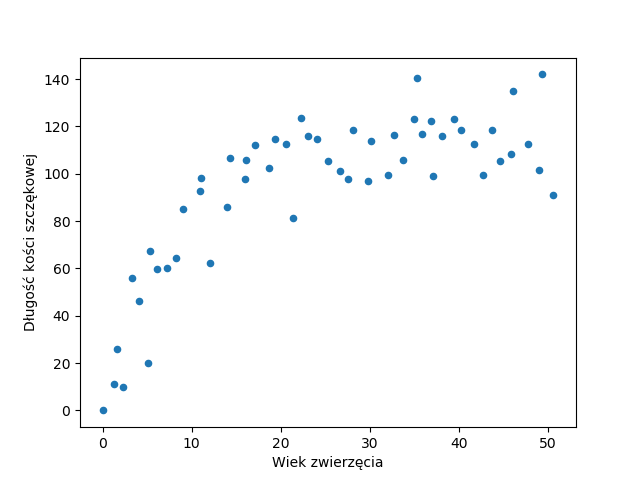

Na powyższym wykresie widać, że zależność na pewno nie jest liniowa. Szczęka zwierzęcia rośnie do pewnego wieku i później jej długość jest stała przez resztę życia. Spróbujemy rozwiązać ten problem za pomocą regresji wielomianowej.


### Zadanie 1
Aby stworzyć funkcję wielomianową konieczne jest dodanie nowych cech do istniejącego zestawu danych.  
Stwórz funkcję, która przetransformuje pojedynczą cechę do wektora cech, w którym kolejne elementy, to kolejne potęgi danej cechy. 

Przykład:  
transform_to_polynomial_feature(x, 5) -> $[x^1, x^2, x^3, x^4, x^5]$  
transform_to_polynomial_feature(x, 3) -> $[x^1, x^2, x^3]$

In [1]:
import numpy as np

'''
input:
x - wartość zmiennej niezależnej
n - stopień wielomianu

output:
out: [] - lista o długości n z kolejnymi potęgami wejściowej cechy x
'''
def transform_to_polynomial_feature(x: np.ndarray, n: int) -> np.ndarray:
    out = []
    # YOUR CODE HERE
    for i in range(1, n + 1):
        out.append(x**i)
    return np.array(out)

### Zadanie 2

Zmodyfikuj swój kod z zadania z regresją liniową tak, aby dla zestawu danych x z jedną zmienną niezależną tworzył nieliniową funkcję regresji. Przetestuj rozwiązanie dla różnych wariantów stopnia wielomianu.
Pamiętaj, że konieczne dodanie dodatkowych cech do oryginalnego zbioru danych, które będą kolejnymi potęgami zmiennej niezależnej - wiek zwierzęcia. 

**UWAGA:** Przed podaniem zestawu danych na wejście modelu pomocna może okazać się operacja normalizacji danych, której celem jest sprowadzenie wartości cech do wspólnych przedziałów wartości. Aby to osiągnąc można wykorzystać [gotowe rozwiązania do standaryzacji lub skalowania min-max](https://scikit-learn.org/stable/modules/preprocessing.html) albo zaimplementować skalowanie samemu korzystając ze [wzoru](https://pl.wikipedia.org/wiki/Standaryzacja_(statystyka)).


--- Polynomial Regression with Degree 1 ---
Final Coefficients (beta_0, beta_1, ..., beta_n): [93.97904757 24.77820281]
Final Mean Squared Error: 239.39041451694024


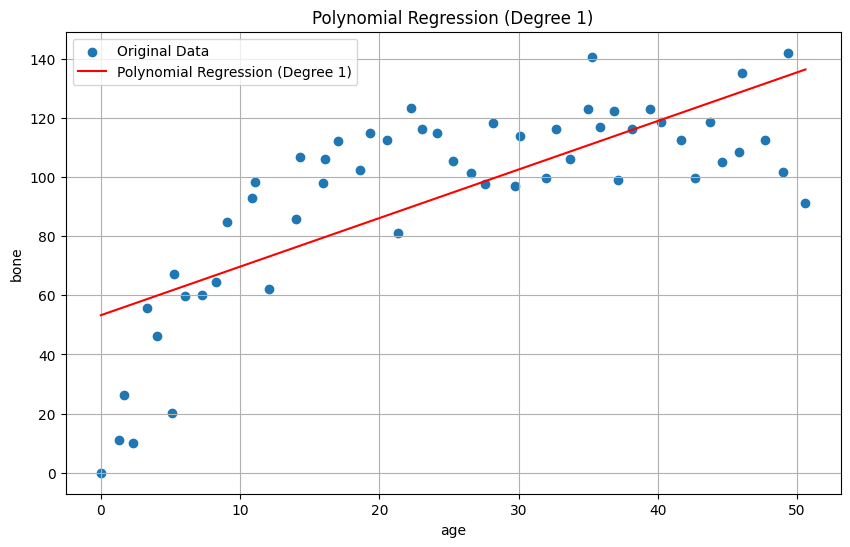

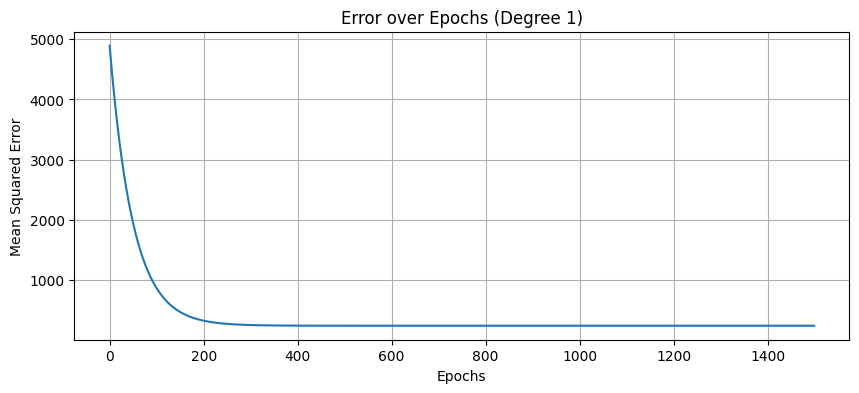


--- Polynomial Regression with Degree 2 ---
Final Coefficients (beta_0, beta_1, ..., beta_n): [111.73151831  24.94674651 -18.00043054]
Final Mean Squared Error: 108.52837663078031


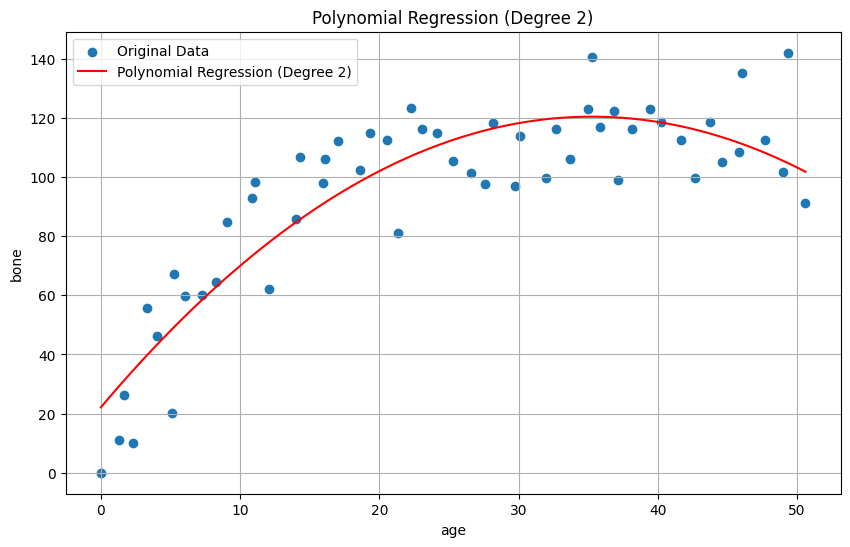

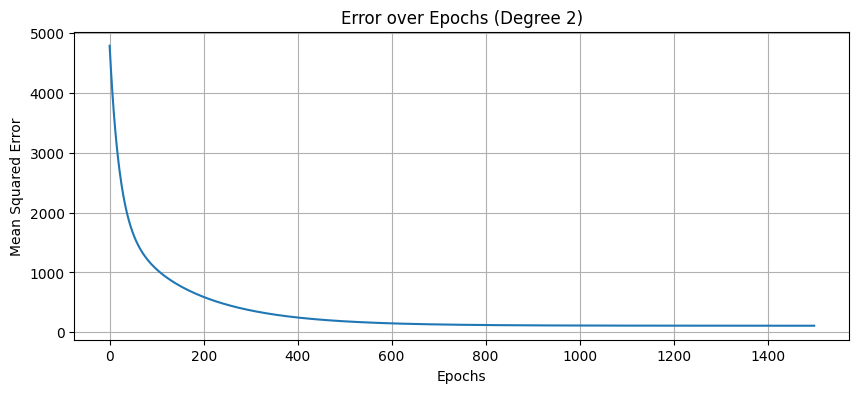


--- Polynomial Regression with Degree 3 ---
Final Coefficients (beta_0, beta_1, ..., beta_n): [112.36533584   9.77188571 -18.71951406   8.64039671]
Final Mean Squared Error: 86.41110396456057


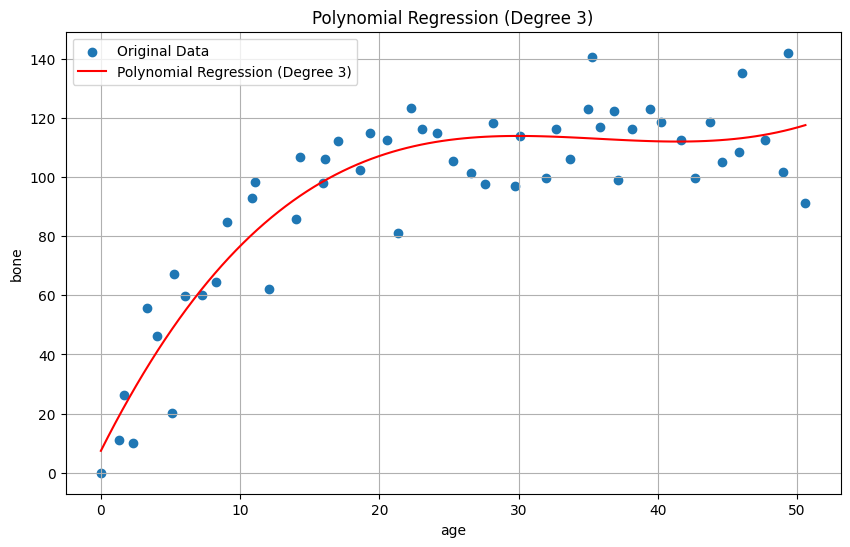

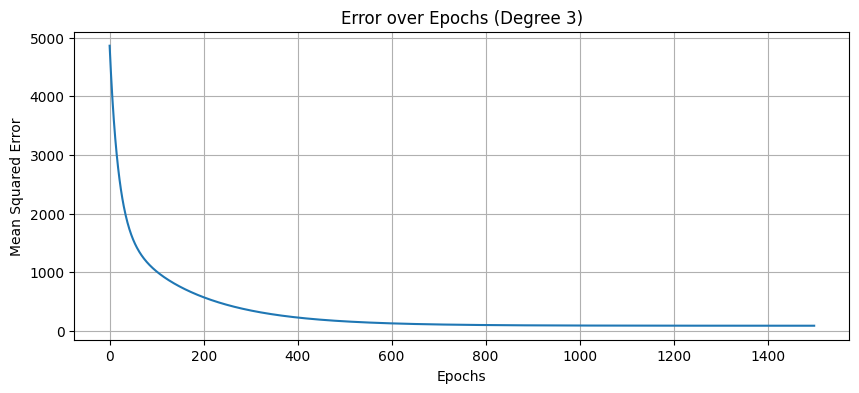


--- Polynomial Regression with Degree 5 ---
Final Coefficients (beta_0, beta_1, ..., beta_n): [102.65371992   8.58512276  11.71231014   9.13614153 -11.8141253
   0.2966464 ]
Final Mean Squared Error: 90.10552206620582


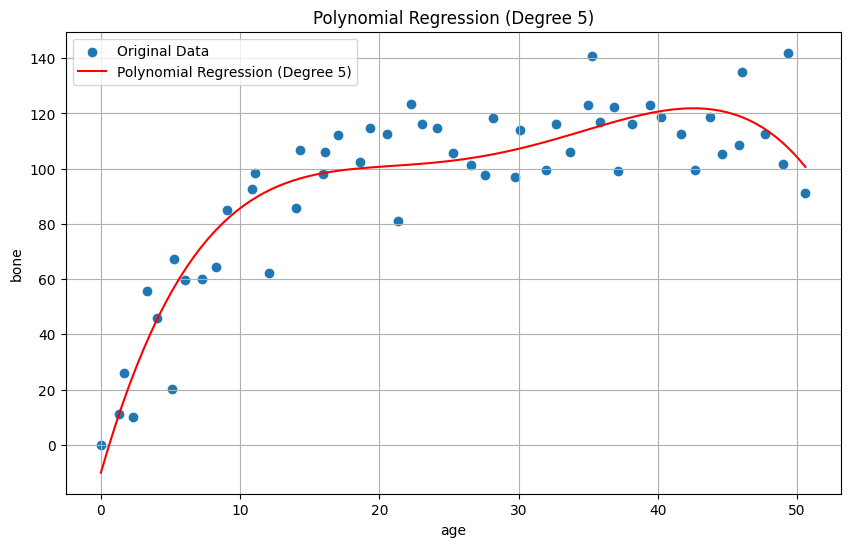

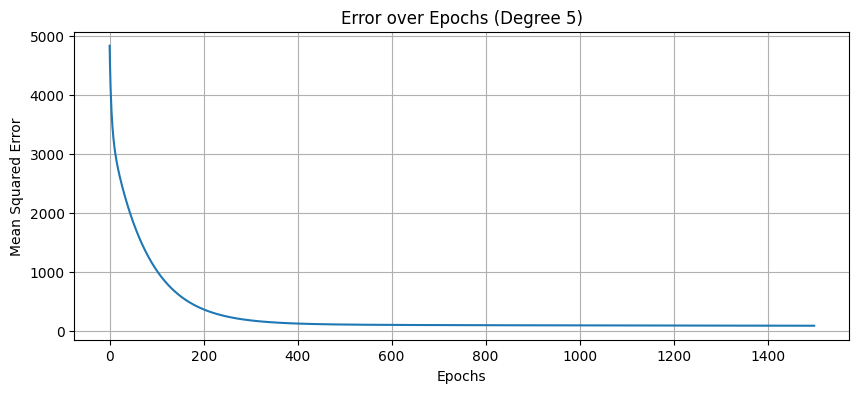

In [2]:
# YOUR CODE HERE
import pandas as pd
import numpy as np
from typing import Tuple
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

def initialize_coefficients(n_features: int) -> Tuple[np.ndarray, float]:
    beta = np.random.rand(n_features + 1)
    alpha = 0.01
    return beta, alpha

def calculate_polynomial_regression_function(x_poly: np.ndarray, beta: np.ndarray) -> np.ndarray:
    return np.dot(x_poly, beta)

def calculate_error_polynomial(predictions: np.ndarray, y: np.ndarray, beta: np.ndarray) -> float:
    m = len(y)
    squared_errors = (predictions - y) ** 2
    ssr = (1 / (2 * m)) * np.sum(squared_errors)
    return ssr

def calculate_gradient_polynomial(predictions: np.ndarray, y: np.ndarray, x_poly: np.ndarray) -> np.ndarray:
    m = len(y)
    gradient = (1 / m) * np.dot(x_poly.T, (predictions - y))
    return gradient

def update_regression_coefficients_polynomial(x_poly: np.ndarray, y: np.ndarray, beta: np.ndarray, alpha: float) -> np.ndarray:
    predictions = calculate_polynomial_regression_function(x_poly, beta)
    gradient = calculate_gradient_polynomial(predictions, y, x_poly)
    beta = beta - alpha * gradient
    return beta

def learn_and_fit_polynomial(x: np.ndarray, y: np.ndarray, degree: int, epochs: int = 1000, normalize: bool = False) -> Tuple[np.ndarray, np.ndarray]:
    if normalize:
        scaler = StandardScaler()
        x_scaled = scaler.fit_transform(x.reshape(-1, 1))
    else:
        x_scaled = x.reshape(-1, 1)

    x_poly = np.hstack([np.ones((len(x), 1))] + [x_scaled**i for i in range(1, degree + 1)])

    beta, alpha = initialize_coefficients(degree)
    beta_history = [beta.copy()]
    error_history = []

    for _ in range(epochs):
        predictions = calculate_polynomial_regression_function(x_poly, beta)
        error = calculate_error_polynomial(predictions, y, beta)
        gradient = calculate_gradient_polynomial(predictions, y, x_poly)
        beta = update_regression_coefficients_polynomial(x_poly, y, beta, alpha)
        beta_history.append(beta.copy())
        error_history.append(error)

    return np.array(beta_history), np.array(error_history)



df = pd.read_csv("Jaws.csv")

x = df['age'].values
y = df['bone'].values

# Test with different polynomial degrees
degrees = [1, 2, 3, 5]

for degree in degrees:
    print(f"\n--- Polynomial Regression with Degree {degree} ---")
    beta_history, error_history = learn_and_fit_polynomial(x, y, degree, epochs=1500, normalize=True)
    final_beta = beta_history[-1]
    final_error = error_history[-1]
    print("Final Coefficients (beta_0, beta_1, ..., beta_n):", final_beta)
    print("Final Mean Squared Error:", final_error)

    # Visualization
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, label='Original Data')

    x_plot = np.linspace(x.min(), x.max(), 100)
    x_scaler = StandardScaler().fit(x.reshape(-1, 1))
    x_plot_scaled = x_scaler.transform(x_plot.reshape(-1, 1))

    x_plot_poly = np.hstack([np.ones((len(x_plot), 1))] + [x_plot_scaled**i for i in range(1, degree + 1)])
    y_plot = np.dot(x_plot_poly, final_beta)

    plt.plot(x_plot, y_plot, color='red', label=f'Polynomial Regression (Degree {degree})')
    plt.xlabel('age')
    plt.ylabel('bone')
    plt.title(f'Polynomial Regression (Degree {degree})')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(error_history)
    plt.xlabel('Epochs')
    plt.ylabel('Mean Squared Error')
    plt.title(f'Error over Epochs (Degree {degree})')
    plt.grid(True)
    plt.show()

### Zadanie 3

Porównaj czasy działania algorytmu dla danych przed i po normalizacji

In [3]:
# YOUR CODE HERE
import time

for degree in degrees:
    start_time = time.time()
    beta_history, error_history = learn_and_fit_polynomial(x, y, degree, epochs=1000, normalize=True)
    end_time = time.time()
    print(f"Normalizacja=True, Degree: {degree}: {end_time - start_time}s")
    
    start_time = time.time()
    beta_history, error_history = learn_and_fit_polynomial(x, y, degree, epochs=1000, normalize=False)
    end_time = time.time()
    print(f"Normalizacja=False, Degree: {degree}: {end_time - start_time}s\n")

Normalizacja=True, Degree: 1: 0.024049997329711914s
Normalizacja=False, Degree: 1: 0.019997119903564453s

Normalizacja=True, Degree: 2: 0.015848636627197266s
Normalizacja=False, Degree: 2: 0.015804767608642578s

Normalizacja=True, Degree: 3: 0.017664670944213867s
Normalizacja=False, Degree: 3: 0.015840768814086914s

Normalizacja=True, Degree: 5: 0.020141124725341797s
Normalizacja=False, Degree: 5: 0.021783113479614258s



c:\Users\Piotr\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Piotr\AppData\Local\Temp\ipykernel_1948\4155105823.py:18: RuntimeWarning: overflow encountered in square
  squared_errors = (predictions - y) ** 2
C:\Users\Piotr\AppData\Local\Temp\ipykernel_1948\4155105823.py:18: RuntimeWarning: overflow encountered in square
  squared_errors = (predictions - y) ** 2
C:\Users\Piotr\AppData\Local\Temp\ipykernel_1948\4155105823.py:18: RuntimeWarning: overflow encountered in square
  squared_errors = (predictions - y) ** 2
C:\Users\Piotr\AppData\Local\Temp\ipykernel_1948\4155105823.py:18: RuntimeWarning: overflow encountered in square
  squared_errors = (predictions - y) ** 2


### Zadanie 4

Stwórz wykres na którym będą znajdować się dane ze zbioru _jaws.csv_ oraz funkcje regresji wielomianowej dla wielomianu pierwszego, czwartego i piątego stopnia. 

Opisz wykres. Jak zmienia się funkcja regresji wraz z dodawaniem kolejnych stopni wielomianu? Czy widzisz jakąś inną możliwą transformację funkcji regresji tak, żeby rozwiązała analizowany problem?

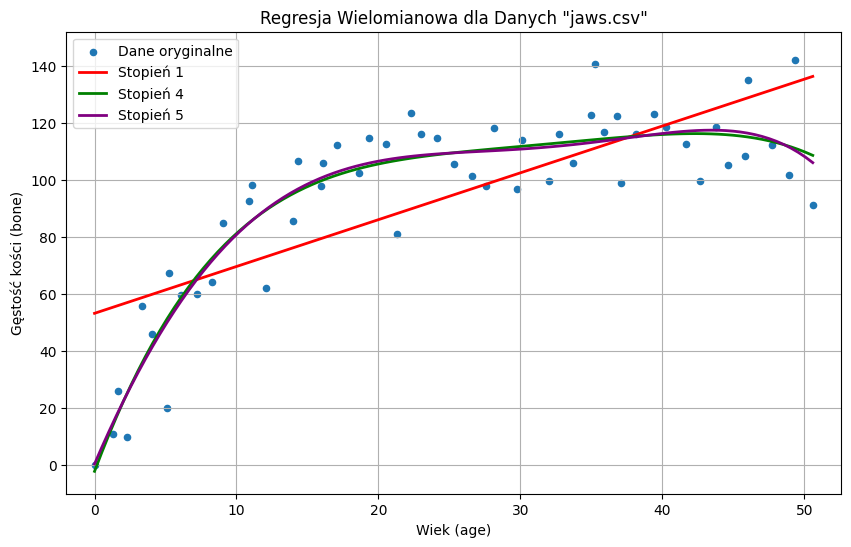

In [4]:
# YOUR CODE HERE
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

df = pd.read_csv("Jaws.csv")
x = df['age'].values.reshape(-1, 1)
y = df['bone'].values.flatten() 
colors = ['red', 'green', 'purple', 'yellow']
labels = ['Stopień 1', 'Stopień 4', 'Stopień 5']
degrees = [1, 4, 5]
plt.figure(figsize=(10, 6))
plt.scatter(x, y, label='Dane oryginalne', s=20)

# Trenowanie i rysowanie funkcji regresji dla każdego stopnia
for i, degree in enumerate(degrees):
    # Użycie Pipeline do połączenia standaryzacji, transformacji wielomianowej i regresji liniowej
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('poly_features', PolynomialFeatures(degree=degree)),
        ('linear_reg', LinearRegression())
    ])
    pipeline.fit(x, y)

    # Generowanie punktów do narysowania funkcji regresji
    x_plot = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
    y_plot = pipeline.predict(x_plot)

    plt.plot(x_plot, y_plot, color=colors[i], label=labels[i], linewidth=2)

# Opis wykresu
plt.xlabel('Wiek (age)')
plt.ylabel('Gęstość kości (bone)')
plt.title('Regresja Wielomianowa dla Danych "jaws.csv"')
plt.legend()
plt.grid(True)
plt.ylim(y.min() - 10, y.max() + 10) # Ustawienie zakresu osi Y dla lepszej widoczności
plt.xlim(x.min() - 2, x.max() + 2)   # Ustawienie zakresu osi X

# Wyświetlenie wykresu
plt.show()

### Zadanie 5

Odszukaj dowolny inny zbiór danych, dokonaj jego wizualizacji i przetestuj działania algorytmu

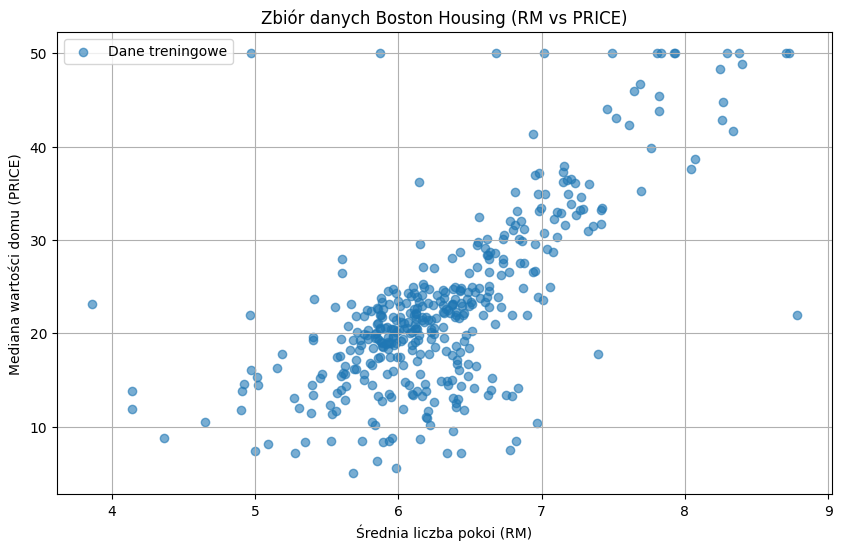

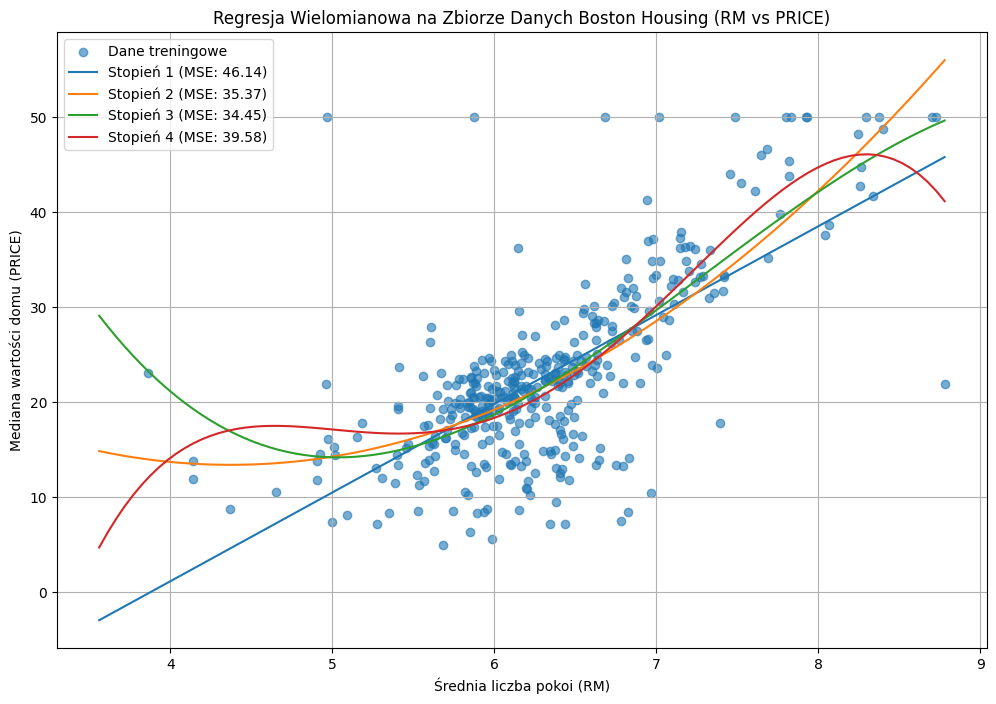


Mean Squared Error na zbiorze testowym dla różnych stopni wielomianu:
Stopień 1: 46.14
Stopień 2: 35.37
Stopień 3: 34.45
Stopień 4: 39.58


In [5]:
# YOUR CODE HERE
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Wczytanie danych z OpenML
boston = fetch_openml(name='boston', version=1, as_frame=True)
data = boston.data
data['PRICE'] = boston.target

# Przygotowanie danych
X = data['RM'].values.reshape(-1, 1)  # Reshape X for single feature
y = data['PRICE'].values

# Podzielmy dane na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Wizualizacja danych treningowych
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, label='Dane treningowe', alpha=0.6)
plt.xlabel('Średnia liczba pokoi (RM)')
plt.ylabel('Mediana wartości domu (PRICE)')
plt.title('Zbiór danych Boston Housing (RM vs PRICE)')
plt.legend()
plt.grid(True)
plt.show()

# Testowanie algorytmu regresji wielomianowej dla różnych stopni
degrees = [1, 2, 3, 4]
results = {}

plt.figure(figsize=(12, 8))
plt.scatter(X_train, y_train, label='Dane treningowe', alpha=0.6)
plt.xlabel('Średnia liczba pokoi (RM)')
plt.ylabel('Mediana wartości domu (PRICE)')
plt.title('Regresja Wielomianowa na Zbiorze Danych Boston Housing (RM vs PRICE)')

x_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

for degree in degrees:
    # Tworzenie i trenowanie modelu Pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('poly_features', PolynomialFeatures(degree=degree)),
        ('linear_reg', LinearRegression())
    ])
    pipeline.fit(X_train, y_train)

    # Predykcja na zbiorze testowym
    y_pred = pipeline.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    results[f'Stopień {degree}'] = mse

    # Wizualizacja funkcji regresji
    pipeline_unscaled = Pipeline([
        ('poly_features', PolynomialFeatures(degree=degree)),
        ('linear_reg', LinearRegression())
    ])
    pipeline_unscaled.fit(X_train, y_train)
    y_plot = pipeline_unscaled.predict(x_plot)
    plt.plot(x_plot, y_plot, label=f'Stopień {degree} (MSE: {mse:.2f})')

plt.legend()
plt.grid(True)
plt.show()

# Wyświetlenie wyników MSE
print("\nMean Squared Error na zbiorze testowym dla różnych stopni wielomianu:")
for degree, mse in results.items():
    print(f"{degree}: {mse:.2f}")

### Zadanie 6

Zaproponuj metrykę oceny skuteczności działania algorytmu. Można wzorować się na metodach dostępnych pod odnośnikiem: https://scikit-learn.org/stable/modules/classes.html#module-sklearn.metrics

In [6]:
# #YOUR CODE HERE
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import math

results = {}

for degree in degrees:
    # Tworzenie i trenowanie modelu Pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('poly_features', PolynomialFeatures(degree=degree)),
        ('linear_reg', LinearRegression())
    ])
    pipeline.fit(X_train, y_train)

    # Predykcja na zbiorze testowym
    y_pred = pipeline.predict(X_test)

    # Obliczenie metryk oceny
    mse = mean_squared_error(y_test, y_pred)
    rmse = math.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    results[f'Stopień {degree}'] = {'MSE': mse, 'RMSE': rmse, 'R2': r2, 'MAE': mae}

# Wyświetlenie wyników metryk oceny
print("\nWyniki metryk oceny na zbiorze testowym dla różnych stopni wielomianu:")
for degree, metrics in results.items():
    print(f"\n{degree}:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.2f}")


Wyniki metryk oceny na zbiorze testowym dla różnych stopni wielomianu:

Stopień 1:
  MSE: 46.14
  RMSE: 6.79
  R2: 0.37
  MAE: 4.48

Stopień 2:
  MSE: 35.37
  RMSE: 5.95
  R2: 0.52
  MAE: 4.16

Stopień 3:
  MSE: 34.45
  RMSE: 5.87
  R2: 0.53
  MAE: 4.08

Stopień 4:
  MSE: 39.58
  RMSE: 6.29
  R2: 0.46
  MAE: 4.23
